# Bootes-DESI AGN Spectra
Benjamin Floyd

For targets of interest in the Boötes field, pulls the 1D spectra from the DESI database and displays them.

In [1]:
from desi_extract_spectra import get_spectrum

INFO:spectra.py:451:read_spectra: iotime 4.514 sec to read spectra from:  coadd-main-dark-9135.fits at 2025-09-15T08:07:55.890828
INFO:coaddition.py:1023:coadd_cameras: coadding spectra across cameras took: 0.136 [sec]


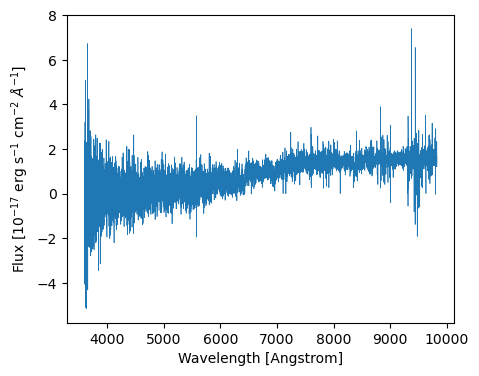

In [3]:
spectra, plot_fig = get_spectrum(target_id, survey, program, healpix, desi_release, make_plot=True)

In [4]:
healpix_grp = healpix // 100
target_dir = Path(f'/dvs_ro/cfs/cdirs/desi/spectro/redux/{desi_release}/healpix/{survey}/{program}/{healpix_grp}/{healpix}')
redrock_path = target_dir / f'redrock-{survey}-{program}-{healpix}.fits'
redrock_details_path = target_dir / f'rrdetails-{survey}-{program}-{healpix}.h5'
redrock_cat = Table.read(redrock_path, hdu='REDSHIFTS')

z_catalog = redrock_cat[redrock_cat['TARGETID'] == target_id]

In [6]:
redrock_details = match_rrdetails_to_spectra(redrock_details_path, spectra)

In [12]:
plotspectra(spectra, zcatalog=z_catalog, redrock_cat=redrock_details, mask_type='DESI_TARGET', notebook=True, with_vi_widgets=False)

Loading BokehJS ...

In [ ]:
spectra.get